# Hyperparameter Tuning: GD and GA with Optuna

This notebook uses **Optuna** to find the best hyperparameters for both the
Gradient Descent (Adam) and Genetic Algorithm (DEAP) approaches.

Results are saved to `results/best_params.json`.  
`main.ipynb` loads that file automatically so the final comparison always
uses the best-known configuration.

## How the search works

**Grid search** tries every combination: 4 values x 3 parameters = 64 fixed configs.  
**Random search** samples randomly: cheap and surprisingly strong when few parameters matter.  
**Bayesian optimisation (TPE)** does neither -- it builds a probabilistic model of the objective:

1. After each trial it fits two densities over the search space:  
   `l(x)` -- the distribution of configs that gave *good* results  
   `g(x)` -- the distribution of configs that gave *bad* results  
2. The next config to evaluate is the one that maximises `l(x)/g(x)`.  
3. As trials accumulate the model gets sharper and focuses the search.

This makes Optuna dramatically more sample-efficient than grid or random search,
especially when the objective is expensive (like training a neural network or running a GA).

**Pruning** adds another layer of efficiency: Optuna can stop a trial early  
if its intermediate values (val acc after each epoch or generation) are already  
well below the median of completed trials at the same step.


In [3]:
try:
    import optuna
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'optuna'], check=True)
    import optuna

import json, os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import torch
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'torch'], check=True)
    import torch
import torch.nn as nn
import torch.nn.utils as nn_utils
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
try:
    from deap import base, creator, tools
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'deap'], check=True)
    from deap import base, creator, tools

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})

BLUE   = '#1565C0'
ORANGE = '#F57C00'
PINK   = '#C2185B'
SAVE   = dict(dpi=150, bbox_inches='tight')

os.makedirs('results/figures', exist_ok=True)


## Tuning budget

Adjust these constants to trade off search quality against wall-clock time.

| Constant | Default | Meaning |
|---|---|---|
| `GD_N_TRIALS` | 60 | Optuna trials for GD; each trains for `GD_TUNE_EPOCHS` epochs |
| `GD_TUNE_EPOCHS` | 60 | Epochs per GD trial (full run uses 150; 60 captures convergence trend) |
| `GA_N_TRIALS` | 20 | Optuna trials for GA; each runs up to `GA_TUNE_NGEN` generations |
| `GA_TUNE_NGEN` | 100 | Max generations per GA trial |
| `GA_PATIENCE` | 25 | Stop a GA trial early if best val acc has not improved for N generations |

Estimated wall time with defaults: GD ~12 min, GA ~10-25 min (depends on pruning).


In [4]:
GD_N_TRIALS    = 60    # Optuna trials for GD
GD_TUNE_EPOCHS = 60    # Epochs per GD trial
GA_N_TRIALS    = 20    # Optuna trials for GA
GA_TUNE_NGEN   = 100   # Generations per GA trial
GA_PATIENCE    = 25    # Early-stop within a GA trial if no improvement

RANDOM_SEED = 42
BATCH_SIZE  = 64


## 1 · Data setup

Identical split to `main.ipynb`: 70% train / 10% val / 20% test, stratified,
StandardScaler fit on train only.  The validation set is the optimisation target.


In [5]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

df    = pd.read_csv('data/extracted_audio_features.csv')
X_raw = df.drop(columns=['class']).values.astype(np.float32)
le    = LabelEncoder()
y_raw = le.fit_transform(df['class']).astype(np.int64)

X_tmp,   X_test,  y_tmp,   y_test  = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=RANDOM_SEED)
X_train, X_val,   y_train, y_val   = train_test_split(
    X_tmp, y_tmp, test_size=0.125, stratify=y_tmp, random_state=RANDOM_SEED)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

X_train_t = torch.tensor(X_train);  y_train_t = torch.tensor(y_train)
X_val_t   = torch.tensor(X_val);    y_val_t   = torch.tensor(y_val)
X_test_t  = torch.tensor(X_test);   y_test_t  = torch.tensor(y_test)

N_FEATURES, N_CLASSES = X_train.shape[1], len(le.classes_)
print(f'Train {X_train.shape[0]}  Val {X_val.shape[0]}  Test {X_test.shape[0]}'
      f'  |  {N_FEATURES} features  {N_CLASSES} classes')


Train 6071  Val 868  Test 1735  |  34 features  10 classes


## 2 · Model and helper functions

The MLP is identical to `main.ipynb`.  `hidden_dim` is treated as a tunable
hyperparameter here so we must pass it explicitly instead of using a fixed default.


In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim=34, hidden_dim=20, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)


def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X).argmax(1) == y).float().mean().item()


def val_ce_loss(model):
    """Cross-entropy loss on the validation set (used as GA fitness signal)."""
    model.eval()
    with torch.no_grad():
        return nn.CrossEntropyLoss()(model(X_val_t), y_val_t).item()


def set_weights(model, weights):
    nn_utils.vector_to_parameters(
        torch.tensor(weights, dtype=torch.float32), model.parameters())


def count_params(hidden_dim):
    return N_FEATURES * hidden_dim + hidden_dim + hidden_dim * N_CLASSES + N_CLASSES


print('MLP (h=20):', count_params(20), 'params')


MLP (h=20): 910 params


## 3 · GD Hyperparameter Tuning

### Search space

| Parameter | Range | Scale | Reason |
|---|---|---|---|
| `lr` | [1e-4, 1e-2] | log | Step sizes act multiplicatively; equal log-spacing explores sensibly |
| `weight_decay` | [1e-6, 1e-2] | log | Same reasoning -- small vs large regularisation spans orders of magnitude |
| `hidden_dim` | {45, 50, 55, 60, 65} | categorical | Refined search around the coarse optimum of 50 |

### Pruning strategy

`MedianPruner` prunes a trial at epoch `e` if its val acc is below the median
of all completed trials at that same epoch.  `n_startup_trials=10` means the
first 10 trials always run to completion (we need a baseline before pruning makes sense).
`n_warmup_steps=20` delays pruning until epoch 20 because early-epoch val acc is too
noisy and unreliable for ranking configs.

In [7]:
def gd_objective(trial):
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd         = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    hidden_dim = trial.suggest_categorical('hidden_dim', [45, 50, 55, 60, 65])

    torch.manual_seed(RANDOM_SEED)
    model     = MLP(hidden_dim=hidden_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(
        TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE,
        shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))

    for epoch in range(1, GD_TUNE_EPOCHS + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        # Report intermediate value so Optuna can prune bad trials
        val_acc = accuracy(model, X_val_t, y_val_t)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return accuracy(model, X_val_t, y_val_t)

In [8]:
gd_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20),
    study_name='gd_tuning',
)

print(f'Running {GD_N_TRIALS} GD trials ({GD_TUNE_EPOCHS} epochs each) ...')
t0 = time.perf_counter()
gd_study.optimize(gd_objective, n_trials=GD_N_TRIALS)
gd_elapsed = time.perf_counter() - t0

n_complete  = sum(1 for t in gd_study.trials if t.state.name == 'COMPLETE')
n_pruned    = sum(1 for t in gd_study.trials if t.state.name == 'PRUNED')
gd_best     = gd_study.best_params
gd_best_val = gd_study.best_value

print(f'Done in {gd_elapsed:.0f}s  |  {n_complete} complete  {n_pruned} pruned')
print(f'Best val acc : {gd_best_val:.4f}')
print(f'Best params  : lr={gd_best["lr"]:.2e}  '
      f'wd={gd_best["weight_decay"]:.2e}  h={gd_best["hidden_dim"]}')


Running 60 GD trials (60 epochs each) ...
Done in 4269s  |  35 complete  25 pruned
Best val acc : 0.9194
Best params  : lr=4.96e-03  wd=3.29e-05  h=60


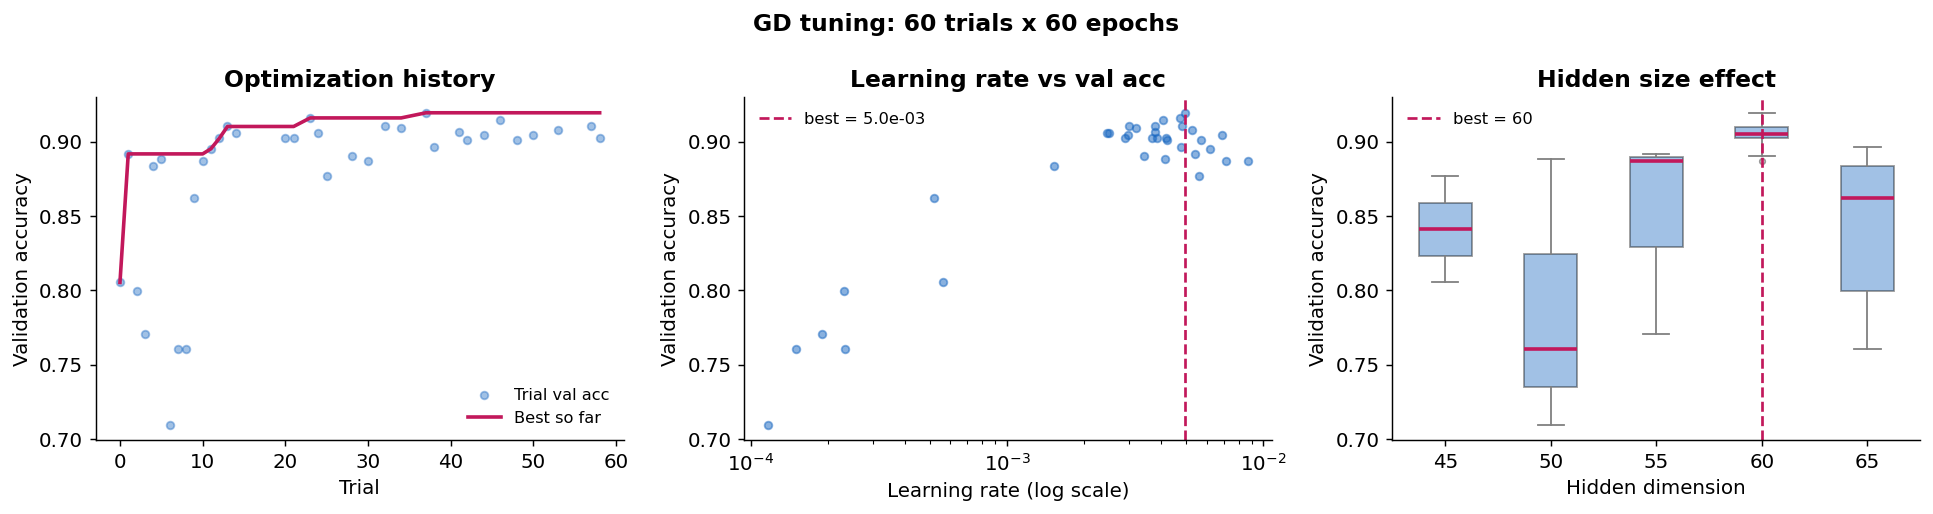

In [9]:
complete_t = [t for t in gd_study.trials if t.state.name == 'COMPLETE']
nums       = [t.number for t in complete_t]
vals       = [t.value  for t in complete_t]
best_curve = np.maximum.accumulate(vals)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(nums, vals, color=BLUE, alpha=0.4, s=18, zorder=2, label='Trial val acc')
axes[0].plot(nums, best_curve, color=PINK, linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Validation accuracy')
axes[0].set_title('Optimization history'); axes[0].legend(frameon=False, fontsize=9)

lrs = [t.params['lr'] for t in complete_t]
axes[1].scatter(lrs, vals, color=BLUE, alpha=0.5, s=18)
axes[1].set_xscale('log')
axes[1].set_xlabel('Learning rate (log scale)'); axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Learning rate vs val acc')
axes[1].axvline(gd_best['lr'], color=PINK, linestyle='--', linewidth=1.5,
                label=f'best = {gd_best["lr"]:.1e}')
axes[1].legend(frameon=False, fontsize=9)

hdims   = sorted(set(int(t.params['hidden_dim']) for t in complete_t))
hd_accs = [[t.value for t in complete_t if int(t.params['hidden_dim']) == h] for h in hdims]
axes[2].boxplot(hd_accs, labels=hdims, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.4),
                medianprops=dict(color=PINK, linewidth=2),
                whiskerprops=dict(color='grey'), capprops=dict(color='grey'),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
best_h_idx = hdims.index(int(gd_best['hidden_dim'])) + 1
axes[2].axvline(best_h_idx, color=PINK, linestyle='--', linewidth=1.5,
                label=f'best = {gd_best["hidden_dim"]}')
axes[2].set_xlabel('Hidden dimension'); axes[2].set_ylabel('Validation accuracy')
axes[2].set_title('Hidden size effect'); axes[2].legend(frameon=False, fontsize=9)

plt.suptitle(f'GD tuning: {GD_N_TRIALS} trials x {GD_TUNE_EPOCHS} epochs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/tuning_gd_optuna.png', **SAVE)
plt.show()


## 4 · GA Hyperparameter Tuning

### Search space

| Parameter | Range | Why it matters |
|---|---|---|
| `pop_size` | {50, 100, 150, 200} | Larger populations explore more but cost more per generation |
| `cxpb` | [0.5, 0.9] | Fraction of offspring produced by crossover vs direct copy |
| `mutpb` | [0.01, 0.20] | Too low -> premature convergence; too high -> destroys good solutions |
| `elite_k` | {1, 3, 5, 8, 10} | How many top individuals survive unchanged each generation |

### Architecture consistency

The GA evolves the weight vector of the same MLP used by GD.
The chromosome length equals `count_params(hidden_dim)`, so we fix
`hidden_dim` to the value found by GD tuning to keep both methods comparable.

### Pruning for the GA

Pruning is harder for GA because early generations always look bad regardless
of config.  `n_warmup_steps=30` delays pruning until generation 30,
giving every trial a fair start before it can be eliminated.


In [10]:
if not hasattr(creator, 'FitnessMax'):
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
if not hasattr(creator, 'Individual'):
    creator.create('Individual', list, fitness=creator.FitnessMax)

_hidden_for_ga = int(gd_best['hidden_dim'])
_n_params_ga   = count_params(_hidden_for_ga)
print(f'Chromosome length: {_n_params_ga}  (hidden_dim = {_hidden_for_ga})')


Chromosome length: 2710  (hidden_dim = 60)


In [11]:
def ga_objective(trial):
    pop_size = trial.suggest_categorical('pop_size', [50, 100, 150, 200])
    cxpb     = trial.suggest_float('cxpb',  0.5, 0.9)
    mutpb    = trial.suggest_float('mutpb',  0.01, 0.20)
    elite_k  = trial.suggest_categorical('elite_k', [1, 3, 5, 8, 10])

    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    ga_model = MLP(hidden_dim=_hidden_for_ga)

    def evaluate(individual):
        set_weights(ga_model, individual)
        return (-val_ce_loss(ga_model),)  # fitness = negative loss (maximise)

    tb = base.Toolbox()
    tb.register('attr_float',  random.gauss, 0.0, 0.1)
    tb.register('individual',  tools.initRepeat, creator.Individual, tb.attr_float, n=_n_params_ga)
    tb.register('population',  tools.initRepeat, list, tb.individual)
    tb.register('evaluate',    evaluate)
    tb.register('mate',        tools.cxBlend,       alpha=0.5)
    tb.register('mutate',      tools.mutGaussian,   mu=0.0, sigma=0.05, indpb=0.05)
    tb.register('select',      tools.selTournament, tournsize=5)

    pop = tb.population(n=pop_size)
    for ind, fit in zip(pop, map(tb.evaluate, pop)):
        ind.fitness.values = fit
    hof = tools.HallOfFame(1)
    hof.update(pop)

    best_val, stagnant = 0.0, 0

    for gen in range(1, GA_TUNE_NGEN + 1):
        offspring = tb.select(pop, pop_size - elite_k)
        offspring = list(map(tb.clone, offspring))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                tb.mate(c1, c2)
                del c1.fitness.values, c2.fitness.values
        for mutant in offspring:
            if random.random() < mutpb:
                tb.mutate(mutant)
                del mutant.fitness.values
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind, fit in zip(invalid, map(tb.evaluate, invalid)):
            ind.fitness.values = fit
        elite  = list(map(tb.clone, tools.selBest(pop, elite_k)))
        pop[:] = offspring + elite
        hof.update(pop)

        set_weights(ga_model, hof[0])
        val_acc = accuracy(ga_model, X_val_t, y_val_t)

        if val_acc > best_val + 1e-4:
            best_val, stagnant = val_acc, 0
        else:
            stagnant += 1

        trial.report(val_acc, gen)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        if stagnant >= GA_PATIENCE:
            break

    return best_val


In [12]:
ga_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30),
    study_name='ga_tuning',
)

print(f'Running {GA_N_TRIALS} GA trials (up to {GA_TUNE_NGEN} gen each, patience={GA_PATIENCE}) ...')
t0 = time.perf_counter()
ga_study.optimize(ga_objective, n_trials=GA_N_TRIALS)
ga_elapsed = time.perf_counter() - t0

ga_complete = sum(1 for t in ga_study.trials if t.state.name == 'COMPLETE')
ga_pruned   = sum(1 for t in ga_study.trials if t.state.name == 'PRUNED')
ga_best     = ga_study.best_params
ga_best_val = ga_study.best_value

print(f'Done in {ga_elapsed:.0f}s  |  {ga_complete} complete  {ga_pruned} pruned')
print(f'Best val acc : {ga_best_val:.4f}')
print(f'Best params  : N={ga_best["pop_size"]}  cxpb={ga_best["cxpb"]:.2f}'
      f'  mutpb={ga_best["mutpb"]:.2f}  k={ga_best["elite_k"]}')


Running 20 GA trials (up to 100 gen each, patience=25) ...
Done in 416s  |  8 complete  12 pruned
Best val acc : 0.6014
Best params  : N=100  cxpb=0.72  mutpb=0.05  k=1


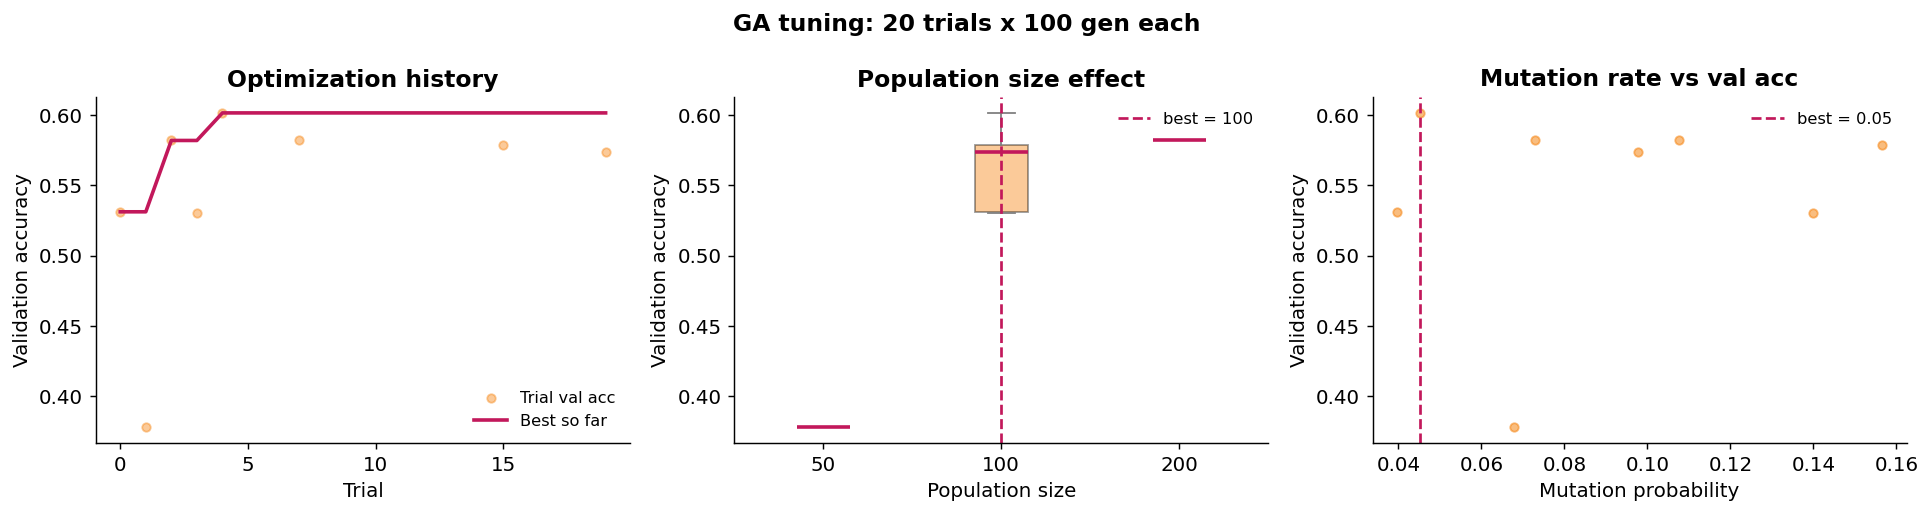

In [13]:
ga_ct      = [t for t in ga_study.trials if t.state.name == 'COMPLETE']
ga_nums    = [t.number for t in ga_ct]
ga_vals    = [t.value  for t in ga_ct]
ga_best_curve = np.maximum.accumulate(ga_vals)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(ga_nums, ga_vals, color=ORANGE, alpha=0.4, s=22, zorder=2, label='Trial val acc')
axes[0].plot(ga_nums, ga_best_curve, color=PINK, linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Validation accuracy')
axes[0].set_title('Optimization history'); axes[0].legend(frameon=False, fontsize=9)

pop_vals = sorted(set(int(t.params['pop_size']) for t in ga_ct))
pa = [[t.value for t in ga_ct if int(t.params['pop_size']) == p] for p in pop_vals]
axes[1].boxplot(pa, labels=pop_vals, patch_artist=True,
                boxprops=dict(facecolor=ORANGE, alpha=0.4),
                medianprops=dict(color=PINK, linewidth=2),
                whiskerprops=dict(color='grey'), capprops=dict(color='grey'),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
best_p_idx = pop_vals.index(int(ga_best['pop_size'])) + 1
axes[1].axvline(best_p_idx, color=PINK, linestyle='--', linewidth=1.5,
                label=f'best = {ga_best["pop_size"]}')
axes[1].set_xlabel('Population size'); axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Population size effect'); axes[1].legend(frameon=False, fontsize=9)

mutpbs = [t.params['mutpb'] for t in ga_ct]
axes[2].scatter(mutpbs, ga_vals, color=ORANGE, alpha=0.5, s=22)
axes[2].set_xlabel('Mutation probability'); axes[2].set_ylabel('Validation accuracy')
axes[2].set_title('Mutation rate vs val acc')
axes[2].axvline(ga_best['mutpb'], color=PINK, linestyle='--', linewidth=1.5,
                label=f'best = {ga_best["mutpb"]:.2f}')
axes[2].legend(frameon=False, fontsize=9)

plt.suptitle(f'GA tuning: {GA_N_TRIALS} trials x {GA_TUNE_NGEN} gen each',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/tuning_ga_optuna.png', **SAVE)
plt.show()


## 5 · Save best parameters and validate

Save to `results/best_params.json` so `main.ipynb` can pick them up automatically.

Then run a quick validation: retrain both models with tuned vs default params
over the same number of steps (150 epochs for GD, 150 generations for GA).
This checks that the tuned params actually improve over the well-chosen defaults.


In [14]:
best_params = {
    'gd': {
        'lr':           gd_best['lr'],
        'weight_decay': gd_best['weight_decay'],
        'hidden_dim':   int(gd_best['hidden_dim']),
    },
    'ga': {
        'pop_size': int(ga_best['pop_size']),
        'cxpb':     float(ga_best['cxpb']),
        'mutpb':    float(ga_best['mutpb']),
        'elite_k':  int(ga_best['elite_k']),
    },
    'meta': {
        'gd_best_val_acc': round(gd_best_val, 4),
        'ga_best_val_acc': round(ga_best_val, 4),
        'gd_n_trials':     GD_N_TRIALS,
        'ga_n_trials':     GA_N_TRIALS,
        'tuning_date':     pd.Timestamp.now().strftime('%Y-%m-%d'),
    },
}

with open('results/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print('Saved to results/best_params.json')
print(json.dumps(best_params, indent=2))


Saved to results/best_params.json
{
  "gd": {
    "lr": 0.004960719127437833,
    "weight_decay": 3.294900078937187e-05,
    "hidden_dim": 60
  },
  "ga": {
    "pop_size": 100,
    "cxpb": 0.7186841117373118,
    "mutpb": 0.04512234654985014,
    "elite_k": 1
  },
  "meta": {
    "gd_best_val_acc": 0.9194,
    "ga_best_val_acc": 0.6014,
    "gd_n_trials": 60,
    "ga_n_trials": 20,
    "tuning_date": "2026-06-16"
  }
}


### GD: default vs tuned (150 epochs)


In [15]:
def train_gd(lr, wd, hidden_dim, epochs=150):
    torch.manual_seed(RANDOM_SEED)
    model = MLP(hidden_dim=hidden_dim)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    crit  = nn.CrossEntropyLoss()
    ldr   = DataLoader(
        TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE,
        shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
    curve = []
    for _ in range(epochs):
        model.train()
        for xb, yb in ldr:
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        curve.append(accuracy(model, X_val_t, y_val_t))
    return model, curve


print('Training GD with defaults  (lr=1e-3, wd=1e-4, h=20) ...')
gd_def_model, gd_def_curve = train_gd(lr=1e-3, wd=1e-4, hidden_dim=20)

print('Training GD with tuned params ...')
gd_tun_model, gd_tun_curve = train_gd(
    lr=best_params['gd']['lr'],
    wd=best_params['gd']['weight_decay'],
    hidden_dim=best_params['gd']['hidden_dim'])

gd_def_test = accuracy(gd_def_model, X_test_t, y_test_t)
gd_tun_test = accuracy(gd_tun_model, X_test_t, y_test_t)
print(f'Default : val={gd_def_curve[-1]:.4f}  test={gd_def_test:.4f}')
print(f'Tuned   : val={gd_tun_curve[-1]:.4f}  test={gd_tun_test:.4f}')


Training GD with defaults  (lr=1e-3, wd=1e-4, h=20) ...
Training GD with tuned params ...
Default : val=0.8065  test=0.8035
Tuned   : val=0.9044  test=0.8899


### GA: default vs tuned (150 generations)


In [16]:
def run_ga_short(pop_size, cxpb, mutpb, elite_k, ngen=150):
    random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
    m = MLP(hidden_dim=_hidden_for_ga)

    def evaluate(ind):
        set_weights(m, ind)
        return (-val_ce_loss(m),)

    tb = base.Toolbox()
    tb.register('attr_float',  random.gauss, 0.0, 0.1)
    tb.register('individual',  tools.initRepeat, creator.Individual, tb.attr_float, n=_n_params_ga)
    tb.register('population',  tools.initRepeat, list, tb.individual)
    tb.register('evaluate',    evaluate)
    tb.register('mate',        tools.cxBlend,       alpha=0.5)
    tb.register('mutate',      tools.mutGaussian,   mu=0.0, sigma=0.05, indpb=0.05)
    tb.register('select',      tools.selTournament, tournsize=5)

    pop = tb.population(n=pop_size)
    for ind, fit in zip(pop, map(tb.evaluate, pop)):
        ind.fitness.values = fit
    hof = tools.HallOfFame(1)
    hof.update(pop)

    curve = []
    for _ in range(1, ngen + 1):
        offspring = tb.select(pop, pop_size - elite_k)
        offspring = list(map(tb.clone, offspring))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                tb.mate(c1, c2); del c1.fitness.values, c2.fitness.values
        for mutant in offspring:
            if random.random() < mutpb:
                tb.mutate(mutant); del mutant.fitness.values
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind, fit in zip(invalid, map(tb.evaluate, invalid)):
            ind.fitness.values = fit
        elite  = list(map(tb.clone, tools.selBest(pop, elite_k)))
        pop[:] = offspring + elite
        hof.update(pop)
        set_weights(m, hof[0])
        curve.append(accuracy(m, X_val_t, y_val_t))

    return m, curve


print('Running GA with defaults (N=100, cxpb=0.7, mutpb=0.05, k=5) ...')
ga_def_model, ga_def_curve = run_ga_short(pop_size=100, cxpb=0.7, mutpb=0.05, elite_k=5)

print('Running GA with tuned params ...')
ga_tun_model, ga_tun_curve = run_ga_short(
    pop_size=best_params['ga']['pop_size'],
    cxpb=best_params['ga']['cxpb'],
    mutpb=best_params['ga']['mutpb'],
    elite_k=best_params['ga']['elite_k'])

ga_def_test = accuracy(ga_def_model, X_test_t, y_test_t)
ga_tun_test = accuracy(ga_tun_model, X_test_t, y_test_t)
print(f'Default : best val={max(ga_def_curve):.4f}  test={ga_def_test:.4f}')
print(f'Tuned   : best val={max(ga_tun_curve):.4f}  test={ga_tun_test:.4f}')


Running GA with defaults (N=100, cxpb=0.7, mutpb=0.05, k=5) ...
Running GA with tuned params ...
Default : best val=0.6129  test=0.4986
Tuned   : best val=0.6567  test=0.5383


### Summary plot


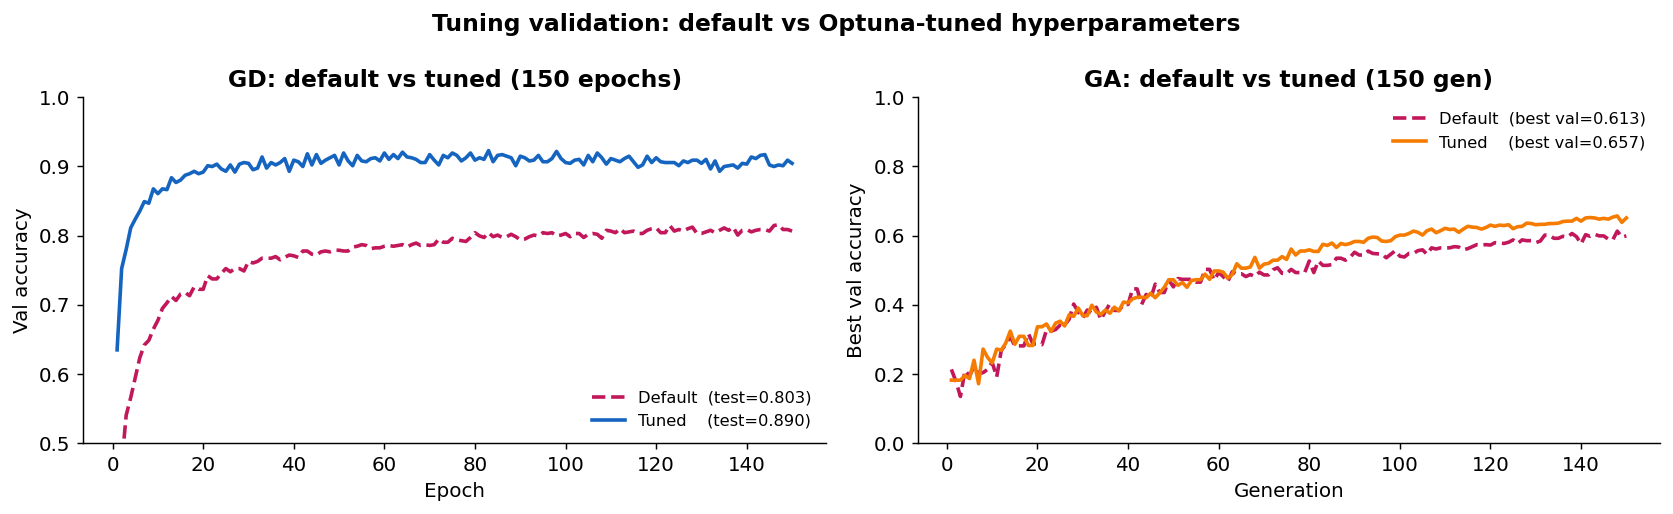

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, 151), gd_def_curve, color=PINK,  linewidth=2, linestyle='--',
             label=f'Default  (test={gd_def_test:.3f})')
axes[0].plot(range(1, 151), gd_tun_curve, color=BLUE,  linewidth=2,
             label=f'Tuned    (test={gd_tun_test:.3f})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val accuracy')
axes[0].set_title('GD: default vs tuned (150 epochs)')
axes[0].set_ylim(0.5, 1.0); axes[0].legend(frameon=False, fontsize=9)

gens = range(1, 151)
axes[1].plot(gens, ga_def_curve, color=PINK,   linewidth=2, linestyle='--',
             label=f'Default  (best val={max(ga_def_curve):.3f})')
axes[1].plot(gens, ga_tun_curve, color=ORANGE, linewidth=2,
             label=f'Tuned    (best val={max(ga_tun_curve):.3f})')
axes[1].set_xlabel('Generation'); axes[1].set_ylabel('Best val accuracy')
axes[1].set_title('GA: default vs tuned (150 gen)')
axes[1].set_ylim(0, 1.0); axes[1].legend(frameon=False, fontsize=9)

plt.suptitle('Tuning validation: default vs Optuna-tuned hyperparameters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/tuning_validation.png', **SAVE)
plt.show()


## Summary

| | GD default | GD tuned | GA default | GA tuned |
|---|---|---|---|---|
| Val acc | `gd_def_curve[-1]` | `gd_tun_curve[-1]` | `max(ga_def_curve)` | `max(ga_tun_curve)` |
| Test acc | `gd_def_test` | `gd_tun_test` | `ga_def_test` | `ga_tun_test` |

The tuned parameters are saved in `results/best_params.json`.
Run `main.ipynb` to use them for the full comparison with all visualisations.


In [18]:
print('GD  default  val={:.4f}  test={:.4f}'.format(gd_def_curve[-1], gd_def_test))
print('GD  tuned    val={:.4f}  test={:.4f}'.format(gd_tun_curve[-1], gd_tun_test))
print('GA  default  val={:.4f}  test={:.4f}'.format(max(ga_def_curve), ga_def_test))
print('GA  tuned    val={:.4f}  test={:.4f}'.format(max(ga_tun_curve), ga_tun_test))


GD  default  val=0.8065  test=0.8035
GD  tuned    val=0.9044  test=0.8899
GA  default  val=0.6129  test=0.4986
GA  tuned    val=0.6567  test=0.5383
